In [1]:
from datasets import load_dataset
ds = load_dataset("weathon/grpo_dataset")

In [2]:
import os
import json
import re
rollouts = os.listdir("rollouts")
okay = 0
total = 0
x = []
y = []
for filename in rollouts:
    idx = int(filename.split(".")[0])
    with open(f"rollouts/{filename}", "r") as f:
        data = json.load(f)
        min_diff = 20
        best = 0
        for r in data:
            score = re.search('<score>(.*?)</score>', r)
            if score is not None:
                try:    
                    score = float(score.group(1))
                    diff = abs(score - ds['train'][idx]['solution'])
                    if diff < min_diff:
                        min_diff = diff
                        best = score
                except Exception as e:
                    pass
        if min_diff < 1:
            okay += 1
        x.append(best)
        y.append(ds['train'][idx]['solution'])
            
        total += 1
print(f"Accuracy: {okay/total if total > 0 else 0}")

Accuracy: 0.7940865892291447


Pearson correlation: 0.7363419034200994


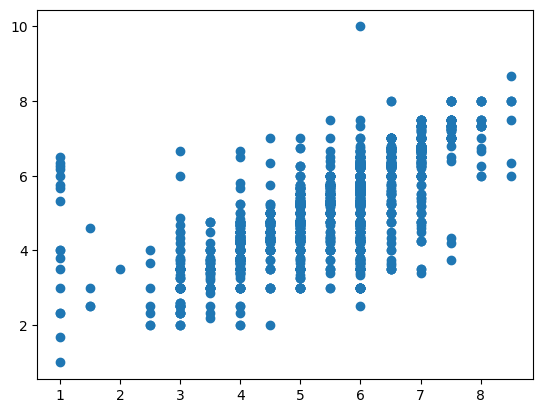

In [3]:
import pylab
from scipy.stats import pearsonr
corr, _ = pearsonr(x, y)
print(f"Pearson correlation: {corr}")
pylab.scatter(x, y)

In [ ]:
def format(ans):
    return [
      {
          "role": "assistant",
          "content": ans
      }
  ]

import os
import json
import re
import numpy as np
rollouts = os.listdir("rollouts")
dpo_ds = []
for filename in rollouts:
    idx = int(filename.split(".")[0])
    gt = ds['train'][idx]['solution']
    with open(f"rollouts/{filename}", "r") as f:
        data = json.load(f)
    min_diff = 20
    best = 0
    scores = []
    for r in data:
        score = re.search('<score>(.*?)</score>', r)
        if score is not None:
            try:    
                score = float(score.group(1))
                scores.append(score)
            except Exception as e:
                print(f"Error parsing score in idx {idx}: {e}")
                scores.append(float('inf'))
    
    
    scores = np.array(scores)
    if np.min(np.abs(scores - gt)) > 3:
        print(f"skipping idx {idx} since all scores are far from gt {gt}")
        continue

    # put the golden sample at the begining so we can slice it
    chosen = np.concatenate([[np.argmin(np.abs(scores - gt))], np.where(np.abs(scores - gt) < 1)[0]])
    chosen = np.unique(chosen)

    this_slide = []
    for c in chosen:
        for i, s in enumerate(scores):
            if abs(s - gt) > abs(scores[c] - gt) and abs(s - gt) > 1:
                this_slide.append({
                    "paper_id": ds['train'][idx]['paper_id'],
                    "prompt": ds['train'][idx]['prompt'],
                    "chosen": format(data[c]),
                    "rejected": format(data[i]),
                    "chosen_diff": abs(scores[c] - gt),
                    "rejected_diff": abs(s - gt), 
                    "gt": gt
                })
            if len(this_slide) > 10:
                break
        if len(this_slide) > 10:
            break
    print(len(this_slide))
    dpo_ds.extend(this_slide)         

In [5]:
len(dpo_ds)

10573

In [6]:
all_ids = list(ds['train']['paper_id'])

In [8]:
dpo_ds_train = [d for d in dpo_ds if d['paper_id'] in all_ids[:-10]]
dpo_ds_test = [d for d in dpo_ds if d['paper_id'] in all_ids[-10:]]

In [9]:
from datasets import Dataset, DatasetDict
dpo_ds_train = Dataset.from_list(dpo_ds_train)
dpo_ds_test = Dataset.from_list(dpo_ds_test)
dpo_ds = DatasetDict(
    {
        "train": dpo_ds_train,
        "test": dpo_ds_test
    }
)

In [10]:
dpo_ds.push_to_hub("weathon/dpo_ds_hf")

Uploading the dataset shards:   0%|          | 0/4 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/weathon/dpo_ds_hf/commit/4c0a9fb973f2c66b9902796dd143b4c2daebbb86', commit_message='Upload dataset', commit_description='', oid='4c0a9fb973f2c66b9902796dd143b4c2daebbb86', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/weathon/dpo_ds_hf', endpoint='https://huggingface.co', repo_type='dataset', repo_id='weathon/dpo_ds_hf'), pr_revision=None, pr_num=None)